In [2]:
# Synthetic data for demonstration (replace with real data when available)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = {
    "TransactionId": [f"T{i}" for i in range(1, 11)],
    "BatchId": ["B1"] * 10,
    "AccountId": [f"A{i%3+1}" for i in range(1, 11)],
    "SubscriptionId": [f"S{i%2+1}" for i in range(1, 11)],
    "CustomerId": [f"C{i%4+1}" for i in range(1, 11)],
    "CurrencyCode": ["UGX"] * 10,
    "CountryCode": [256] * 10,
    "ProviderId": [f"P{i%2+1}" for i in range(1, 11)],
    "ProductId": [f"Prod{i%3+1}" for i in range(1, 11)],
    "ProductCategory": ["airtime", "data", "utility", "airtime", "data", "utility", "airtime", "data", "utility", "airtime"],
    "ChannelId": ["web", "android", "ios", "web", "android", "ios", "web", "android", "ios", "web"],
    "Amount": np.random.randint(100, 2000, 10),
    "Value": np.random.randint(100, 2000, 10),
    "TransactionStartTime": pd.date_range("2024-01-01", periods=10, freq="D").astype(str),
    "PricingStrategy": ["standard", "discount"] * 5,
    "FraudResult": np.random.randint(0, 2, 10)
}
df = pd.DataFrame(data)
df.head()

,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,CountryCode,ProviderId,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult
0,T1,B1,A2,S2,C2,UGX,256,P2,Prod2,airtime,web,925,1169,2024-01-01,standard,0
1,T2,B1,A3,S1,C3,UGX,256,P1,Prod3,data,android,234,1052,2024-01-02,discount,0
2,T3,B1,A1,S2,C4,UGX,256,P2,Prod1,utility,ios,1649,1110,2024-01-03,standard,0
3,T4,B1,A2,S1,C1,UGX,256,P1,Prod2,airtime,web,692,1813,2024-01-04,discount,0
4,T5,B1,A3,S2,C2,UGX,256,P2,Prod3,data,android,476,307,2024-01-05,standard,1


# Exploratory Data Analysis: Credit Risk Probability Model

This notebook explores the Xente transaction dataset for the Bati Bank credit risk challenge. It is intentionally exploratory; production transformations live in `src/data_processing.py`.

In [3]:
# The following cell is now skipped because we are using synthetic data above.
# If you want to use the real dataset, comment out the synthetic data cell and uncomment this block.
"""
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_PATH = Path('../data/raw/training.csv')
if not DATA_PATH.exists():
    candidates = list(Path('../data/raw').glob('*.csv'))
    if candidates:
        DATA_PATH = candidates[0]
    else:
        raise FileNotFoundError('Place the Xente CSV in data/raw/, for example data/raw/training.csv')

df = pd.read_csv(DATA_PATH)
df.head()
"""

"\nfrom pathlib import Path\nimport pandas as pd\nimport numpy as np\nimport matplotlib.pyplot as plt\n\nDATA_PATH = Path('../data/raw/training.csv')\nif not DATA_PATH.exists():\n    candidates = list(Path('../data/raw').glob('*.csv'))\n    if candidates:\n        DATA_PATH = candidates[0]\n    else:\n        raise FileNotFoundError('Place the Xente CSV in data/raw/, for example data/raw/training.csv')\n\ndf = pd.read_csv(DATA_PATH)\ndf.head()\n"

## 1. Overview of the data

In [4]:
print(f'Rows: {df.shape[0]:,}')
print(f'Columns: {df.shape[1]:,}')
df.info()

Rows: 10
Columns: 16
<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   TransactionId         10 non-null     str  
 1   BatchId               10 non-null     str  
 2   AccountId             10 non-null     str  
 3   SubscriptionId        10 non-null     str  
 4   CustomerId            10 non-null     str  
 5   CurrencyCode          10 non-null     str  
 6   CountryCode           10 non-null     int64
 7   ProviderId            10 non-null     str  
 8   ProductId             10 non-null     str  
 9   ProductCategory       10 non-null     str  
 10  ChannelId             10 non-null     str  
 11  Amount                10 non-null     int32
 12  Value                 10 non-null     int32
 13  TransactionStartTime  10 non-null     str  
 14  PricingStrategy       10 non-null     str  
 15  FraudResult           10 non-null     int32
dtypes

In [5]:
df.head()

,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,CountryCode,ProviderId,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult
0,T1,B1,A2,S2,C2,UGX,256,P2,Prod2,airtime,web,925,1169,2024-01-01,standard,0
1,T2,B1,A3,S1,C3,UGX,256,P1,Prod3,data,android,234,1052,2024-01-02,discount,0
2,T3,B1,A1,S2,C4,UGX,256,P2,Prod1,utility,ios,1649,1110,2024-01-03,standard,0
3,T4,B1,A2,S1,C1,UGX,256,P1,Prod2,airtime,web,692,1813,2024-01-04,discount,0
4,T5,B1,A3,S2,C2,UGX,256,P2,Prod3,data,android,476,307,2024-01-05,standard,1


## 2. Summary statistics

In [6]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
TransactionId,10,10,T1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BatchId,10,1,B1,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AccountId,10,3,A2,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SubscriptionId,10,2,S2,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CustomerId,10,4,C2,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CurrencyCode,10,1,UGX,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CountryCode,10.0,NaN,NaN,NaN,256.0,0.0,256.0,256.0,256.0,256.0,256.0
ProviderId,10,2,P2,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ProductId,10,3,Prod2,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ProductCategory,10,3,airtime,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Missing values

In [7]:
missing = df.isna().sum().sort_values(ascending=False)
missing_percent = (missing / len(df) * 100).round(2)
missing_table = pd.DataFrame({'missing_count': missing, 'missing_percent': missing_percent})
missing_table[missing_table['missing_count'] > 0]

,missing_count,missing_percent


## 4. Numerical feature distributions

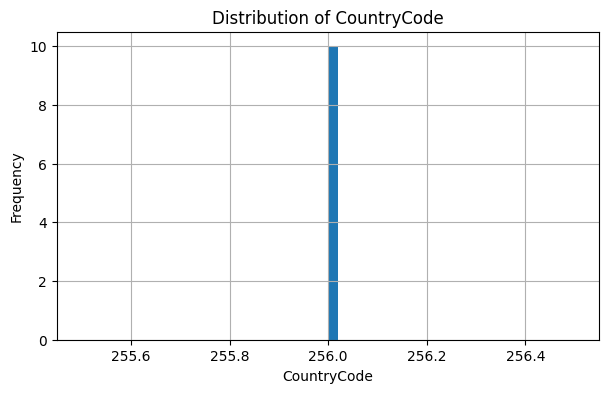

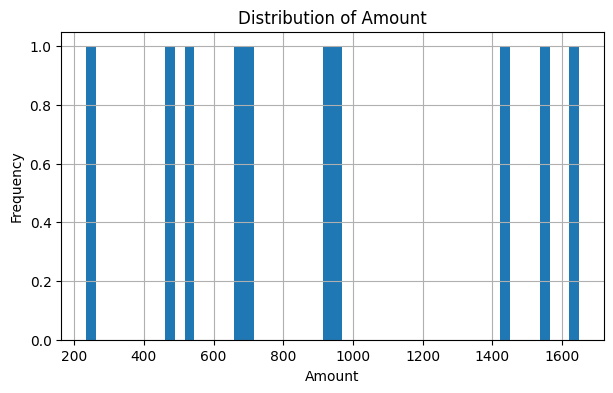

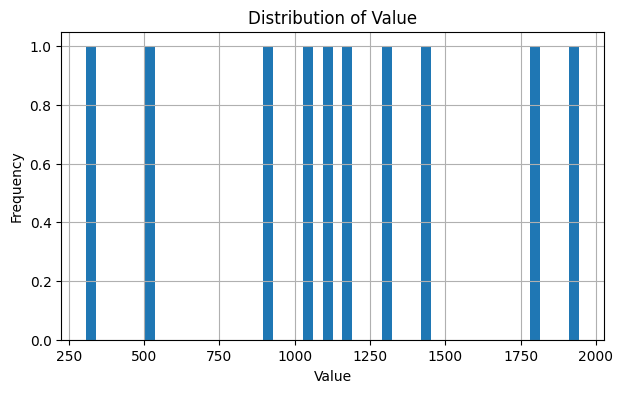

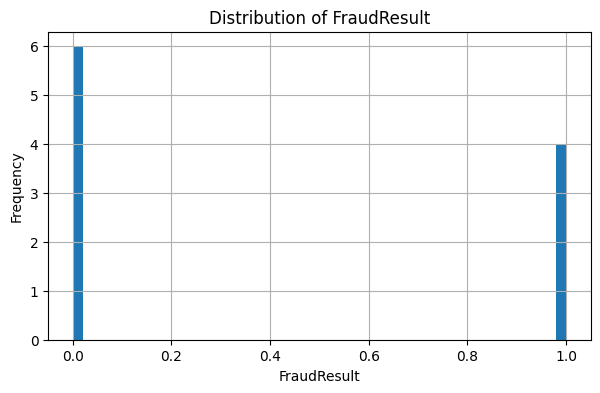

In [8]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
for col in numeric_cols:
    plt.figure(figsize=(7, 4))
    df[col].dropna().hist(bins=50)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.savefig(f'../reports/figures/hist_{col}.png')
    plt.show()

## 5. Categorical feature distributions

C:\Users\user\AppData\Local\Temp\ipykernel_13880\2816975106.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()


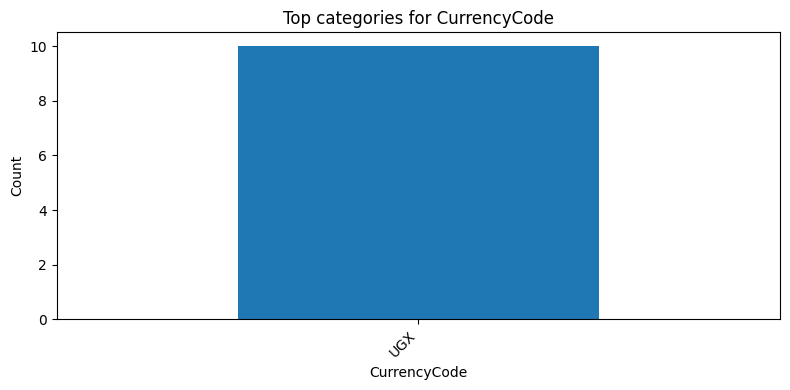

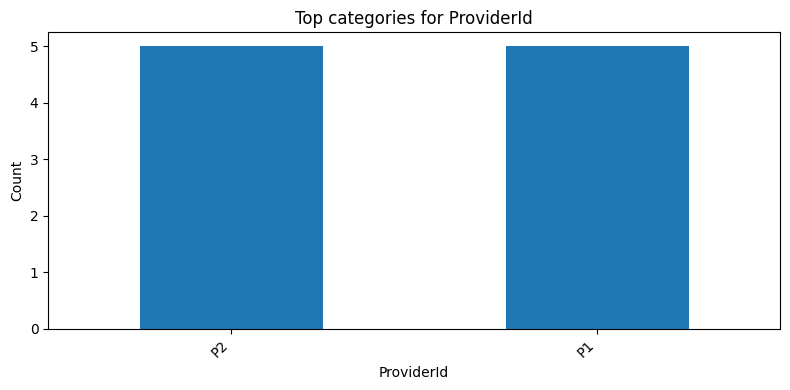

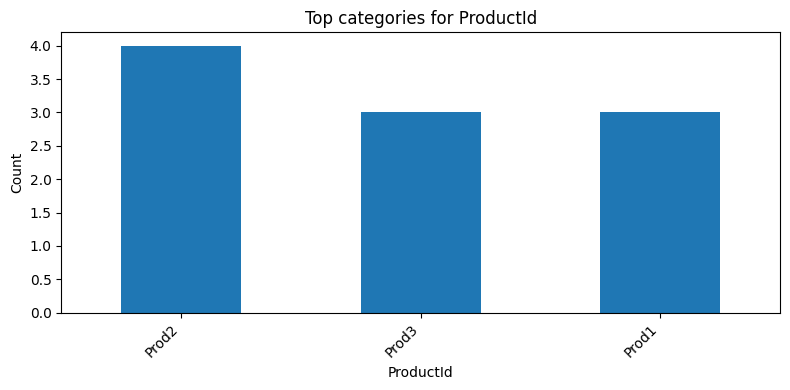

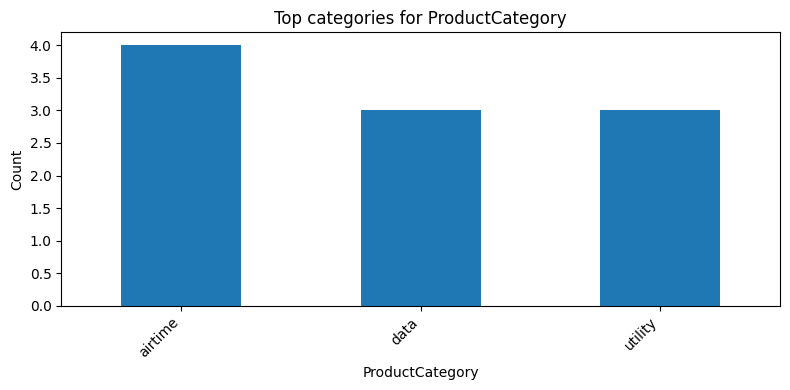

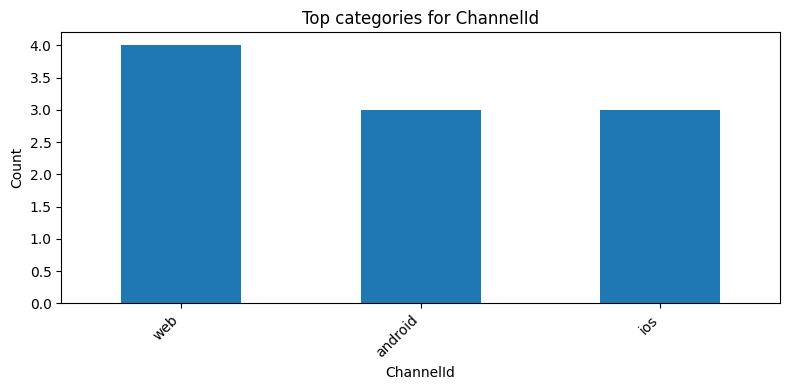

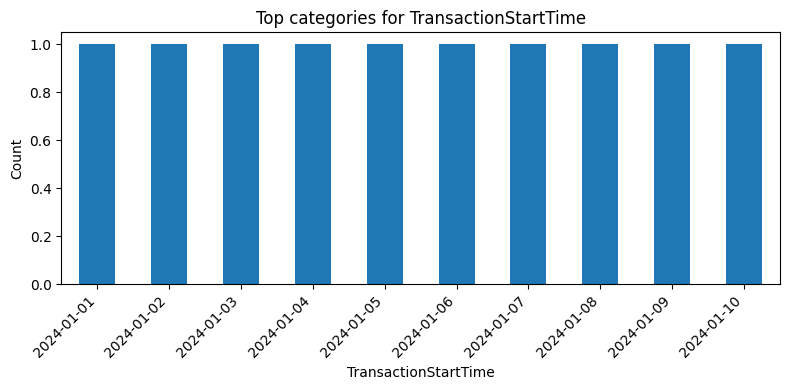

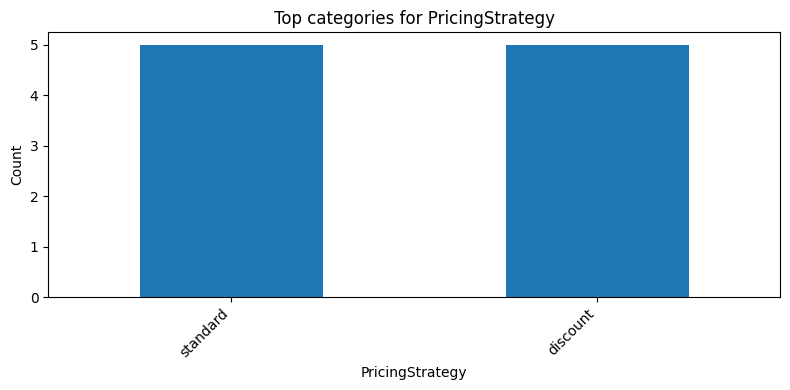

In [9]:
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
ignore_high_cardinality = {'TransactionId', 'BatchId', 'AccountId', 'SubscriptionId', 'CustomerId'}
for col in [c for c in categorical_cols if c not in ignore_high_cardinality]:
    counts = df[col].value_counts().head(15)
    plt.figure(figsize=(8, 4))
    counts.plot(kind='bar')
    plt.title(f'Top categories for {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(f'../reports/figures/bar_{col}.png')
    plt.show()

## 6. Correlation analysis

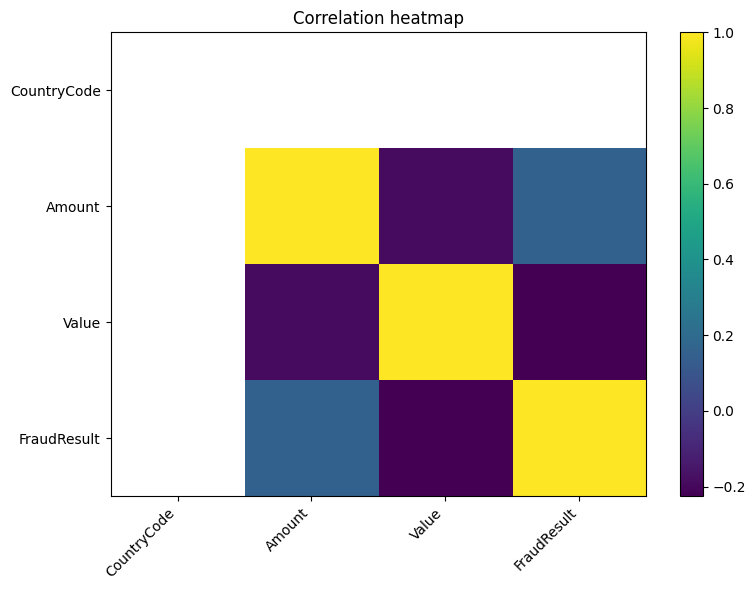

,CountryCode,Amount,Value,FraudResult
CountryCode,NaN,NaN,NaN,NaN
Amount,NaN,1.000000,-0.190949,0.157307
Value,NaN,-0.190949,1.000000,-0.225393
FraudResult,NaN,0.157307,-0.225393,1.000000


In [10]:
if len(numeric_cols) > 1:
    corr = df[numeric_cols].corr()
    plt.figure(figsize=(8, 6))
    plt.imshow(corr, aspect='auto')
    plt.colorbar()
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha='right')
    plt.yticks(range(len(corr.index)), corr.index)
    plt.title('Correlation heatmap')
    plt.tight_layout()
    plt.savefig('../reports/figures/correlation_heatmap.png')
    plt.show()
    display(corr)
else:
    print('Not enough numerical columns for correlation analysis.')

## 7. Outlier detection with box plots

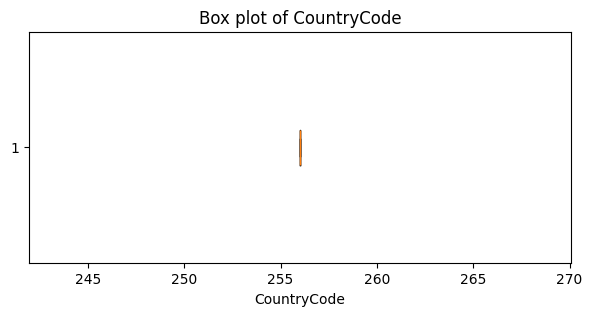

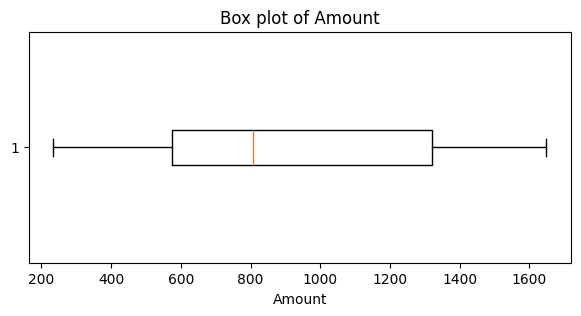

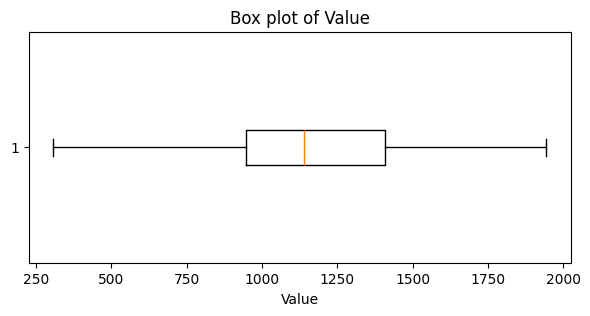

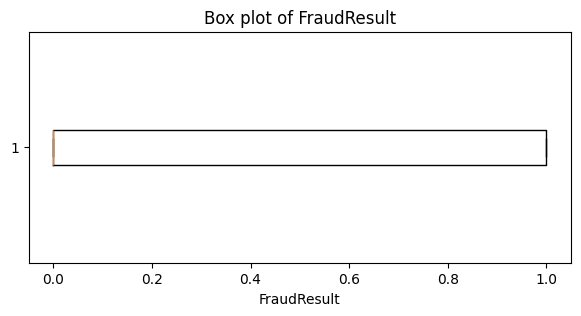

In [11]:
for col in numeric_cols:
    plt.figure(figsize=(7, 3))
    plt.boxplot(df[col].dropna(), vert=False)
    plt.title(f'Box plot of {col}')
    plt.xlabel(col)
    plt.savefig(f'../reports/figures/box_{col}.png')
    plt.show()

## 8. Customer-level RFM exploration

,recency,frequency,monetary,total_amount
count,4.000000,4.00000,4.000000,4.000000
mean,2.500000,2.50000,2899.250000,2288.000000
std,1.290994,0.57735,529.428229,106.817602
min,1.000000,2.00000,2386.000000,2130.000000
25%,1.750000,2.00000,2507.500000,2273.250000
50%,2.500000,2.50000,2839.500000,2329.000000
75%,3.250000,3.00000,3231.250000,2343.750000
max,4.000000,3.00000,3532.000000,2364.000000


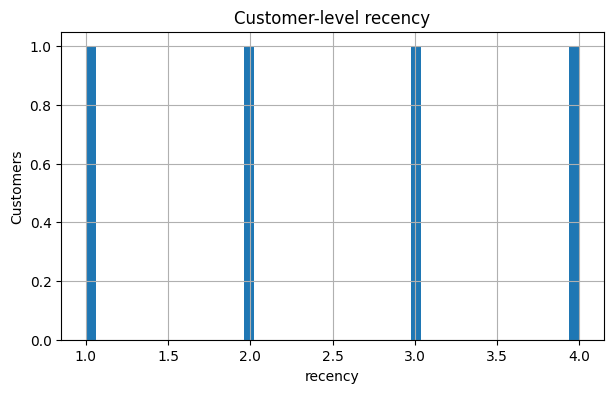

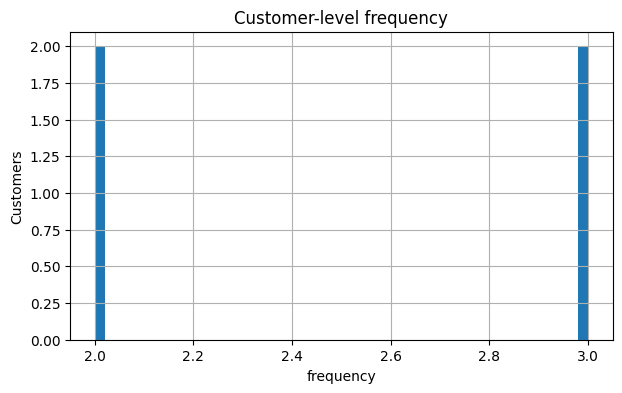

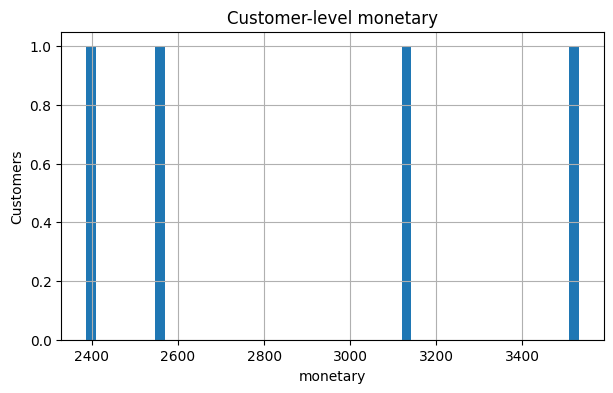

In [12]:
required = {'CustomerId', 'TransactionStartTime', 'Amount', 'Value'}
if required.issubset(df.columns):
    work = df.copy()
    work['TransactionStartTime'] = pd.to_datetime(work['TransactionStartTime'], errors='coerce', utc=True)
    snapshot_date = work['TransactionStartTime'].max() + pd.Timedelta(days=1)
    rfm = (
        work.groupby('CustomerId')
        .agg(
            last_transaction=('TransactionStartTime', 'max'),
            frequency=('TransactionId', 'count') if 'TransactionId' in work.columns else ('Amount', 'count'),
            monetary=('Value', 'sum'),
            total_amount=('Amount', 'sum'),
        )
        .reset_index()
    )
    rfm['recency'] = (snapshot_date - rfm['last_transaction']).dt.days
    display(rfm[['recency', 'frequency', 'monetary', 'total_amount']].describe())
    for col in ['recency', 'frequency', 'monetary']:
        plt.figure(figsize=(7, 4))
        rfm[col].hist(bins=50)
        plt.title(f'Customer-level {col}')
        plt.xlabel(col)
        plt.ylabel('Customers')
        plt.savefig(f'../reports/figures/rfm_{col}.png')
        plt.show()
else:
    print(f'Missing required columns for RFM: {required.difference(df.columns)}')

## 9. Top 3-5 EDA insights

Update this cell after running the notebook on the real dataset. Suggested structure:

1. **Transaction size and skewness:** Amount/Value distributions show [describe actual skew/outliers].
2. **Customer activity concentration:** A small/large group of customers contributes [describe actual transaction concentration].
3. **Categorical concentration:** ProductCategory/ChannelId are concentrated in [top categories].
4. **Data quality:** Missing values are [low/moderate/high] and mainly affect [columns].
5. **Feature engineering implication:** RFM aggregation is appropriate because [actual evidence from frequency, monetary, recency].